In [9]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import mytools
import glob
import os



In [10]:
phiKK_ratio = 1
tritrig_ratio = 14515
wab_ratio = 3247

In [11]:
def get_cosTheta(df):
    df["e_Ptot"] = np.sqrt(df.ele_Px**2 + df.ele_Py**2 + df.ele_Pz**2)
    df["p_Ptot"] = np.sqrt(df.pos_Px**2 + df.pos_Py**2 + df.pos_Pz**2)
    return (df.ele_Px*df.pos_Px+df.ele_Py*df.pos_Py+df.ele_Pz*df.pos_Pz)/(df.e_Ptot*df.p_Ptot)

def get_PmE(df):
    return np.sqrt(df.pos_Px**2 + df.pos_Py**2 + df.pos_Pz**2)-df.pos_E_Ecal

In [12]:
# Load MC data
df_tritrig = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_tritrig_limited.pk')
df_tritrig['PhiKK'] = 0.0
df_phiKK = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_phiKK_limited.pk')
df_phiKK['PhiKK'] = 1.0
df_wab = pd.read_pickle('/Users/mghrear/data/ML_data/patch/2021_v9_pass5_wab_limited.pk')
df_wab['PhiKK'] = 0.0 # Add label

# Make MC test set
# MUST BE CONSISTENT with BDT.ipynb and ANN.ipynb to avoid data leaks!!
tritrig_test = df_tritrig[20000:]
tritrig_test['type']= 'tritrig'
wab_test = df_wab[3000:]
wab_test['type']= 'wab'
phiKK_test = df_phiKK[3000:]
phiKK_test['type']= 'phiKK'

df_test = pd.concat([tritrig_test, phiKK_test,wab_test], ignore_index=True, sort=False)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True) # Now shuffle the combined dataframe

X_test = df_test.drop(columns=['PhiKK','type'])
Y_test = df_test['PhiKK']



/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_94896/3594064593.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tritrig_test['type']= 'tritrig'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_94896/3594064593.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wab_test['type']= 'wab'
/var/folders/fx/czrkltw953xcpcjd85tf2tmm0000gn/T/ipykernel_94896/3594064593.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_inde

In [13]:
# Split into tritrig, wab, background and phiKK dataframes
test_df_tritrig = df_test[df_test['type']=="tritrig"].reset_index(drop=True)
test_df_phiKK = df_test[df_test['type']=="phiKK"].reset_index(drop=True)
test_df_wab = df_test[df_test['type']=="wab"].reset_index(drop=True)
test_df_bkg = pd.concat([test_df_tritrig,test_df_wab])

# Combine dfs according to expected proportions 
k = min(len(test_df_tritrig) // tritrig_ratio, len(test_df_wab) // wab_ratio, len(test_df_phiKK) // phiKK_ratio)
n_tritrig, n_wab, n_phiKK = tritrig_ratio * k, wab_ratio * k, phiKK_ratio * k
print(f"k={k}  tritrig={n_tritrig}  wab={n_wab}  phiKK={n_phiKK}  total={n_tritrig+n_wab+n_phiKK}")

df_test_combined = pd.concat(
    [test_df_tritrig.iloc[:n_tritrig], test_df_wab.iloc[:n_wab], test_df_phiKK.iloc[:n_phiKK]],
    ignore_index=True, sort=False
)

k=1  tritrig=14515  wab=3247  phiKK=1  total=17763


In [15]:
full_data_dir = '/Users/mghrear/data/HPS_data/2021_v9_pass5_processed'
pk_files = glob.glob(os.path.join(full_data_dir, '*.pk'))

def in_dead_zone(x, y):
    cond1 = (y < 31)  & (y > -29)                            # narrow band, full width
    cond2 = (y < 45)  & (y > -45) & (x > -95) & (x < 95)   # wider band, center only
    return cond1 | cond2

results = []
for i, f in enumerate(pk_files):
    print(f'[{i+1}/{len(pk_files)}] {os.path.basename(f)}', end='\r')
    df_i = pd.read_pickle(f)
    fiducial = ~in_dead_zone(df_i.pos_Ecal_x, df_i.pos_Ecal_y)
    chunk = pd.DataFrame({
        'M':        mytools.get_InvM(df_i),
        'cosTheta': get_cosTheta(df_i),
        'PmE':      get_PmE(df_i),
        'fiducial': fiducial.values,
    })
    results.append(chunk)

df_full = pd.concat(results, ignore_index=True)
print(f'\nDone. {len(df_full)} events from {len(pk_files)} files.')

[559/559] merged_hps_014484_job281.pk
Done. 136696941 events from 559 files.


Signal efficiency:     0.6324
Background efficiency: 0.0285


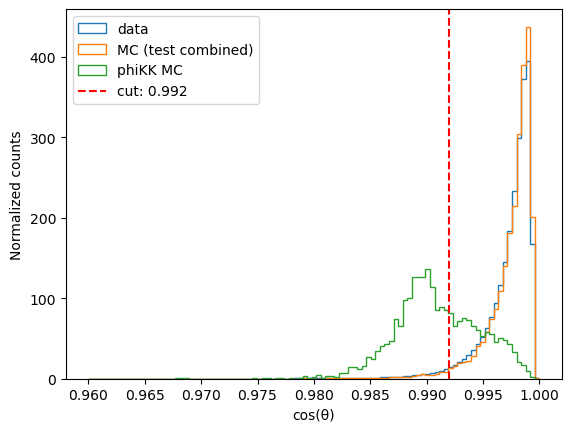

In [16]:
cosTheta_test_combined = get_cosTheta(df_test_combined)
cosTheta_phiKK_mc = get_cosTheta(df_phiKK)

cut = 0.992
sig_before = len(cosTheta_phiKK_mc)
bkg_before = len(cosTheta_test_combined)
sig_after  = (cosTheta_phiKK_mc < cut).sum()
bkg_after  = (cosTheta_test_combined < cut).sum()
print(f'Signal efficiency:     {sig_after/sig_before:.4f}')
print(f'Background efficiency: {bkg_after/bkg_before:.4f}')

bins = np.linspace(0.96, 1, 100)
plt.hist(df_full['cosTheta'], bins=bins, histtype='step', label='data', density=True)
plt.hist(cosTheta_test_combined, bins=bins, histtype='step', label='MC (test combined)', density=True)
plt.hist(cosTheta_phiKK_mc, bins=bins, histtype='step', label='phiKK MC', density=True)
plt.axvline(cut, color='red', linestyle='--', label=f'cut: {cut}')

plt.xlabel('cos(θ)')
plt.ylabel('Normalized counts')
plt.legend()
plt.show()

Best PmE cut: PmE > 0.6593
Signal efficiency:     0.6544
Background efficiency: 0.0151


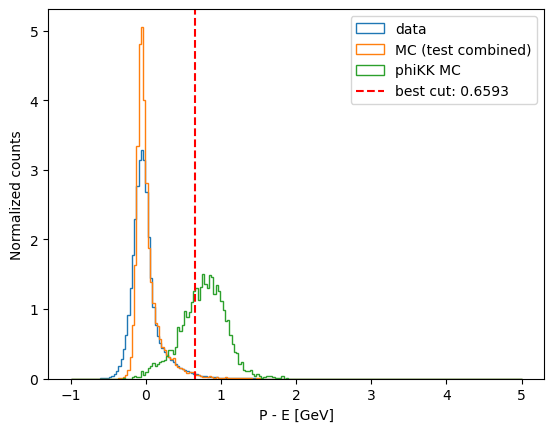

In [17]:
PmE_test_combined = get_PmE(df_test_combined)
PmE_phiKK_mc = get_PmE(df_phiKK)

# Find cut PmE > t that maximizes S/sqrt(B)
thresholds = np.linspace(-1, 5, 500)
sig_eff = np.array([(PmE_phiKK_mc > t).mean() for t in thresholds])
bkg_eff = np.array([(PmE_test_combined > t).mean() for t in thresholds])
cut = thresholds[np.argmax(sig_eff / np.sqrt(bkg_eff + 1e-10))]

sig_before = len(PmE_phiKK_mc)
bkg_before = len(PmE_test_combined)
sig_after  = (PmE_phiKK_mc > cut).sum()
bkg_after  = (PmE_test_combined > cut).sum()
print(f'Best PmE cut: PmE > {cut:.4f}')
print(f'Signal efficiency:     {sig_after/sig_before:.4f}')
print(f'Background efficiency: {bkg_after/bkg_before:.4f}')

bins = np.linspace(-1, 5, 200)
plt.hist(df_full['PmE'], bins=bins, histtype='step', label='data', density=True)
plt.hist(PmE_test_combined, bins=bins, histtype='step', label='MC (test combined)', density=True)
plt.hist(PmE_phiKK_mc, bins=bins, histtype='step', label='phiKK MC', density=True)
plt.axvline(cut, color='red', linestyle='--', label=f'best cut: {cut:.4f}')

plt.xlabel('P - E [GeV]')
plt.ylabel('Normalized counts')
plt.legend()
plt.show()

Events passing both cuts: 97867 / 136696941


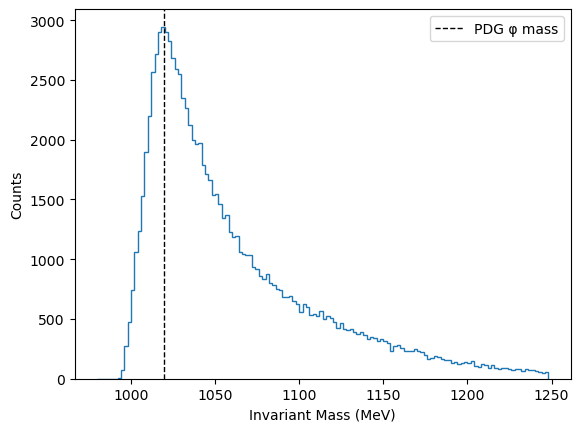

In [20]:
cosTheta_cut = 0.992

PmE_thresholds = np.linspace(-1, 5, 500)
sig_eff = np.array([(PmE_phiKK_mc > t).mean() for t in PmE_thresholds])
bkg_eff = np.array([(PmE_test_combined > t).mean() for t in PmE_thresholds])
PmE_cut = PmE_thresholds[np.argmax(sig_eff / np.sqrt(bkg_eff + 1e-10))]

mask = (df_full['cosTheta'] < cosTheta_cut) & (df_full['PmE'] > PmE_cut) & df_full['fiducial']
df_full_sel = df_full[mask]
print(f'Events passing both cuts: {len(df_full_sel)} / {len(df_full)}')

plt.hist(df_full_sel['M'] * 1000, bins=np.arange(980, 1250, 2), histtype='step')
plt.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG φ mass')
plt.xlabel('Invariant Mass (MeV)')
plt.ylabel('Counts')
plt.legend()
plt.show()

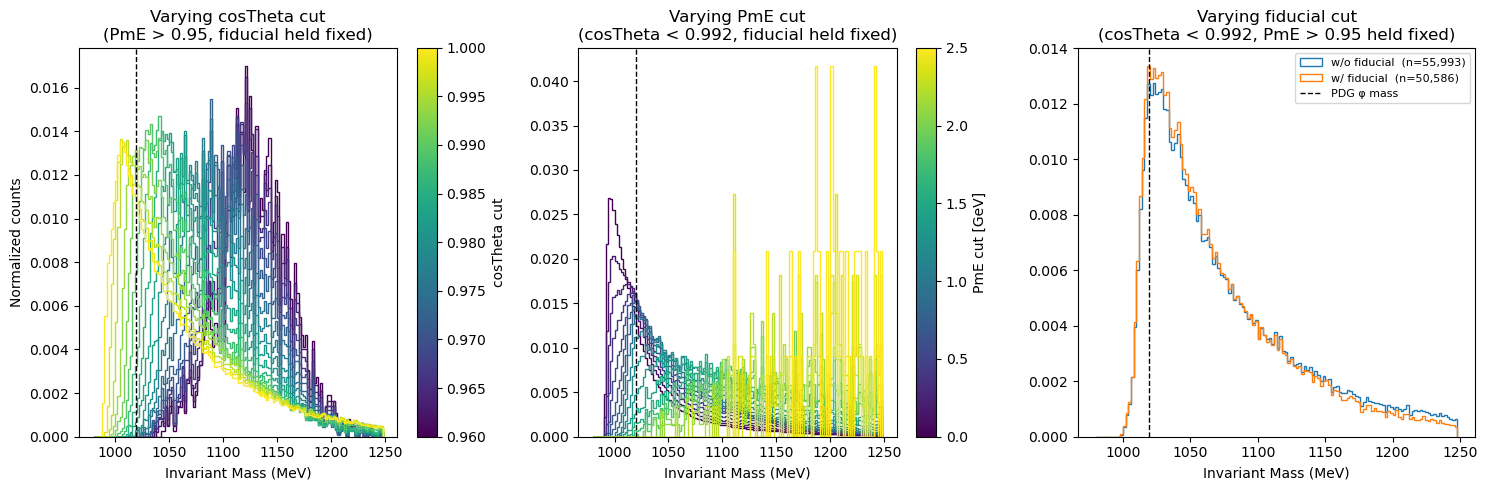

In [77]:
PmE_cut      = 0.95
cosTheta_cut = 0.992

c = df_full['cosTheta'] < cosTheta_cut
p = df_full['PmE']      > PmE_cut
f = df_full['fiducial']

bins = np.arange(980, 1250, 2)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Panel 1: vary cosTheta cut, hold PmE + fiducial ---
ax = axes[0]
cosTheta_trials = np.linspace(0.96, 1.0, 20)
colors = plt.cm.viridis(np.linspace(0, 1, len(cosTheta_trials)))
for t, col in zip(cosTheta_trials, colors):
    mask = (df_full['cosTheta'] < t) & p & f
    ax.hist(df_full.loc[mask, 'M'] * 1000, bins=bins, histtype='step',
            density=True, color=col, label=f'{t:.3f}')
ax.axvline(1019.461, color='k', linestyle='dashed', linewidth=1)
ax.set_title('Varying cosTheta cut\n(PmE > 0.95, fiducial held fixed)')
ax.set_xlabel('Invariant Mass (MeV)')
ax.set_ylabel('Normalized counts')
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(cosTheta_trials.min(), cosTheta_trials.max()))
plt.colorbar(sm, ax=ax, label='cosTheta cut')

# --- Panel 2: vary PmE cut, hold cosTheta + fiducial ---
ax = axes[1]
PmE_trials = np.linspace(0.0, 2.5, 20)
colors = plt.cm.viridis(np.linspace(0, 1, len(PmE_trials)))
for t, col in zip(PmE_trials, colors):
    mask = c & (df_full['PmE'] > t) & f
    ax.hist(df_full.loc[mask, 'M'] * 1000, bins=bins, histtype='step',
            density=True, color=col, label=f'{t:.2f}')
ax.axvline(1019.461, color='k', linestyle='dashed', linewidth=1)
ax.set_title('Varying PmE cut\n(cosTheta < 0.992, fiducial held fixed)')
ax.set_xlabel('Invariant Mass (MeV)')
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(PmE_trials.min(), PmE_trials.max()))
plt.colorbar(sm, ax=ax, label='PmE cut [GeV]')

# --- Panel 3: fiducial on/off, hold cosTheta + PmE ---
ax = axes[2]
for label, mask in [('w/o fiducial', c & p), ('w/ fiducial', c & p & f)]:
    ax.hist(df_full.loc[mask, 'M'] * 1000, bins=bins, histtype='step',
            density=True, label=f'{label}  (n={int(mask.sum()):,})')
ax.axvline(1019.461, color='k', linestyle='dashed', linewidth=1, label='PDG φ mass')
ax.set_title('Varying fiducial cut\n(cosTheta < 0.992, PmE > 0.95 held fixed)')
ax.set_xlabel('Invariant Mass (MeV)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()